# Uniform state preparation (USP) in Workbench
This tutorial shows how to use the [`USP`](../autoapi/workbench_algorithms/subroutines/uniform_state_prep.html#workbench_algorithms.subroutines.uniform_state_prep.USP) qubrick to implement uniform state preparation in Workbench. The subroutine implements the operation

$$
U_{\text{USP}}|0^n\rangle = \sum_{k=0}^{d-1} \frac{1}{\sqrt{d}}|k\rangle \ ,
$$

where $d$ can be any integer $\leq 2^n$.

There are three separate uniform state preparation routines:

- [Encoding electronic spectra in quantum circuits with linear T complexity](https://arxiv.org/abs/1805.03662).
- [Even more efficient quantum computations of chemistry through tensor hypercontraction](https://arxiv.org/abs/2011.03494).
- [An efficient quantum algorithm for preparation of uniform quantum superposition states](https://arxiv.org/abs/2306.11747).

The uniform state preparation routine provided in [arXiv:1805.3662](https://arxiv.org/abs/1805.03662) was made more efficient in [arXiv:2011.03494](https://arxiv.org/abs/2011.03494). More recently, an alternative construction was given in [arXiv:2306:11747](https://arxiv.org/abs/2306.11747) that doesn't use any ancillae qubits. All three uniform state preparation routines are considered and analyzed here. We refer to these routines throughout the notebook as [`USP`](../autoapi/workbench_algorithms/subroutines/uniform_state_prep.html#workbench_algorithms.subroutines.uniform_state_prep.USP), [`RealUSP`](../autoapi/workbench_algorithms/subroutines/uniform_state_prep.html#workbench_algorithms.subroutines.uniform_state_prep.RealUSP) and [`ZeroAncillaUSP`](../autoapi/workbench_algorithms/subroutines/uniform_state_prep.html#workbench_algorithms.subroutines.uniform_state_prep.ZeroAncillaUSP) respectively.

## Uniform state prep ([USP](../autoapi/workbench_algorithms/subroutines/uniform_state_prep.html#workbench_algorithms.subroutines.uniform_state_prep.USP))

When $d$ is a power of 2, USP is implemented simply by applying Hadamard gates. When $d$ is not a power of 2, a more complicated circuit must be used (taken from [figure 12 in "Encoding electronic spectra in quantum circuits with linear $T$ complexity](https://arxiv.org/abs/1805.03662)). Note that in their circuit, the rotation angle used is

$$
\arccos(\frac{2^{\lfloor\log d \rfloor} - d}{d}) \ ,
$$

whereas we use

$$
\arccos(-\frac{2^{\lfloor\log d \rfloor} - d}{d}) \ ,
$$

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

# import qubricks/functions
from workbench_algorithms import USP, RealUSP, ZeroAncillaUSP
from psiqworkbench import QPU, Qubits
from psiqworkbench.utils.bit_utils import num_trailing_zeros
import numpy as np

# plotting
import matplotlib.pyplot as plt

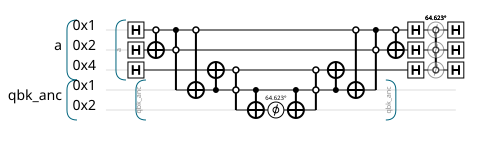

In [2]:
# set up the QPU
qc = QPU()
qc.reset(5)

a = Qubits(3, "a", qc)

# set up USP
usp = USP()
d = 7

# apply the state prep
usp.compute(d, a)

qc.draw()

In [3]:
# check that the correct state is prepared
qc.print_state_vector()

|a|?>
|0|.>    -0.202031+0.319438j
|1|.>    -0.202031+0.319438j
|2|.>    -0.202031+0.319438j
|3|.>    -0.202031+0.319438j
|4|.>    -0.202031+0.319438j
|5|.>    -0.202031+0.319438j
|6|.>    -0.202031+0.319438j


'|a|?>\n|0|.>    -0.202031+0.319438j\n|1|.>    -0.202031+0.319438j\n|2|.>    -0.202031+0.319438j\n|3|.>    -0.202031+0.319438j\n|4|.>    -0.202031+0.319438j\n|5|.>    -0.202031+0.319438j\n|6|.>    -0.202031+0.319438j\n'

If a power of 2 number of amplitudes is requested for any of the `Qubricks` in Workbench Algorithms, the resulting circuit will always be Hadamards.

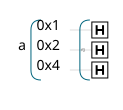

In [4]:
# set up the QPU
qc = QPU()
qc.reset(3)

a = Qubits(3, "a", qc)

# set up USP
usp = USP()
d = 8

# apply the state prep
usp.compute(d, a)

qc.draw()

In [5]:
# check that the correct state is prepared
qc.print_state_vector()

|a>
|0>    0.353553+0.000000j
|1>    0.353553+0.000000j
|2>    0.353553+0.000000j
|3>    0.353553+0.000000j
|4>    0.353553+0.000000j
|5>    0.353553+0.000000j
|6>    0.353553+0.000000j
|7>    0.353553+0.000000j


'|a>\n|0>    0.353553+0.000000j\n|1>    0.353553+0.000000j\n|2>    0.353553+0.000000j\n|3>    0.353553+0.000000j\n|4>    0.353553+0.000000j\n|5>    0.353553+0.000000j\n|6>    0.353553+0.000000j\n|7>    0.353553+0.000000j\n'

We can also control `USP`:

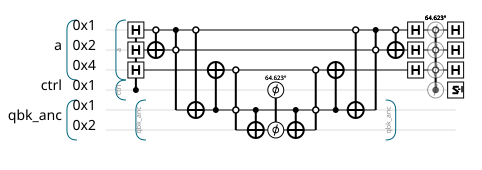

In [6]:
# set up the QPU
qc = QPU()
qc.reset(6)

a = Qubits(3, "a", qc)
ctrl = Qubits(1, "ctrl", qc)

# set up USP
usp = USP()
d = 7

# apply the state prep
usp.compute(d, a, ctrl=ctrl)

qc.draw()

In [7]:
# 1-controlled on the |0> state, so should do nothing
qc.print_state_vector()

|a|ctrl|?>
|0|0|.>    1.000000+0.000000j


'|a|ctrl|?>\n|0|0|.>    1.000000+0.000000j\n'

## Cost of USP

Uniform state preparation is parameterized by $d = 2^k L$. 

In terms of the Toffoli count for the circuit, we have:

1. Cost of inequality test: $\lceil \log_2(d) \rceil - k - 1$ 
2. Cost of rotation $b_r - 3$ (where $b_r \approx 7$).
3. Cost inequality test: $\lceil \log_2(d) \rceil - k - 1$ 
4. Cost of rotation $b_r - 3$ (where $b_r \approx 7$).

This gives a cumulative cost of:

$$    
2(\lceil \log_2(d) \rceil - k - 1) + 8. 
$$

Take for example the case of $d = 6$. Then $k = 1$ and $L = 3$. Then:

In [8]:
d = 6
k = num_trailing_zeros(d)
L = d // 2**k
2*(np.ceil(np.log2(d)) - k - 1) + 8

np.float64(10.0)

## Real uniform state prep ([RealUSP](../autoapi/workbench_algorithms/subroutines/uniform_state_prep.html#workbench_algorithms.subroutines.uniform_state_prep.RealUSP))

In [Even more efficient quantum computations of chemistry through tensor hypercontraction
](https://arxiv.org/abs/2011.03494), the authors present an improved version of USP, which we refer to as *real* uniform state preparation, with the `Qubrick` name `RealUSP`. The specific implementation is given in Appendix A of the paper (steps 1-7 under Eq. A15). A circuit for a similar implementation (but over two input registers) implementation is given in Fig. 3 of the paper. The reason for the name `RealUSP` is that, unlike `USP`, the amplitudes of the resulting output state are real, which is relevant for performing controlled USP.

It should be noted that, in the original paper, the protocol was said to be probabilistic, requiring postselection on the qubit on which the $Y$ rotations were performed, however this does not seem to be the case.

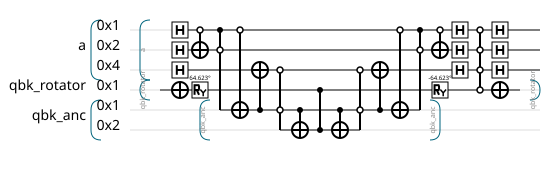

In [9]:
# set up the QPU
qc = QPU()
qc.reset(6)

a = Qubits(3, "a", qc)

# set up USP
usp = RealUSP()
d = 7

# apply the state prep
usp.compute(d, a)

qc.draw()

In [10]:
# check that the correct state is prepared
qc.print_state_vector()

|a|?>
|0|.>    -0.377964+0.000000j
|1|.>    -0.377964+0.000000j
|2|.>    -0.377964+0.000000j
|3|.>    -0.377964+0.000000j
|4|.>    -0.377964+0.000000j
|5|.>    -0.377964+0.000000j
|6|.>    -0.377964+0.000000j


'|a|?>\n|0|.>    -0.377964+0.000000j\n|1|.>    -0.377964+0.000000j\n|2|.>    -0.377964+0.000000j\n|3|.>    -0.377964+0.000000j\n|4|.>    -0.377964+0.000000j\n|5|.>    -0.377964+0.000000j\n|6|.>    -0.377964+0.000000j\n'

We can also control `RealUSP`:

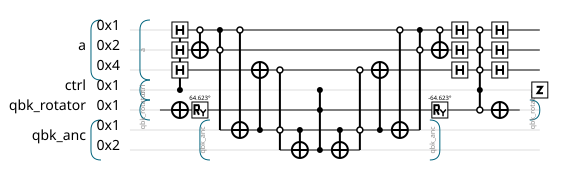

In [11]:
# set up the QPU
qc = QPU()
qc.reset(7)

a = Qubits(3, "a", qc)
ctrl = Qubits(1, "ctrl", qc)

# set up USP
usp = RealUSP()
d = 7

# apply the state prep
usp.compute(d, a, ctrl=ctrl)

qc.draw()

In [12]:
# 1-controlled on the |0> state, so should do nothing
qc.print_state_vector()

|a|ctrl|?>
|0|0|.>    1.000000+0.000000j


'|a|ctrl|?>\n|0|0|.>    1.000000+0.000000j\n'

## Real uniform state prep ([ZeroAncillaUSP](../autoapi/workbench_algorithms/subroutines/uniform_state_prep.html#workbench_algorithms.subroutines.uniform_state_prep.ZeroAncillaUSP))

In [arXiv:2306.11747](https://arxiv.org/abs/2306.11747), the authors provide an alternative formulation of USP that has similar asymptotic scaling but which does not use any ancilla qubits. This version is also implemented in Workbench Algorithms as the `ZeroAncillaUSP` `Qubrick`. It is used in exactly the same way as the other USP `Qubricks` we've looked at:

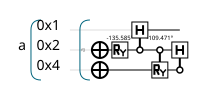

In [13]:
# set up the QPU
qc = QPU()
qc.reset(3)

a = Qubits(3, "a", qc)

# set up USP
usp = ZeroAncillaUSP()
d = 7

# apply the state prep
usp.compute(d, a)

qc.draw()

In [14]:
# check that the correct state is prepared
qc.print_state_vector()

|a>
|0>    0.377964+0.000000j
|1>    0.377964+0.000000j
|2>    0.377964+0.000000j
|3>    0.377964+0.000000j
|4>    0.377964+0.000000j
|5>    0.377964+0.000000j
|6>    0.377964+0.000000j


'|a>\n|0>    0.377964+0.000000j\n|1>    0.377964+0.000000j\n|2>    0.377964+0.000000j\n|3>    0.377964+0.000000j\n|4>    0.377964+0.000000j\n|5>    0.377964+0.000000j\n|6>    0.377964+0.000000j\n'

Like the others, we can also control `ZeroAncillaUSP`:

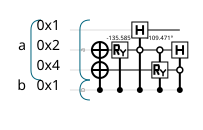

In [15]:
# set up the QPU
qc = QPU()
qc.reset(4)

a = Qubits(3, "a", qc)
b = Qubits(1, "b", qc)

# set up USP
usp = ZeroAncillaUSP()
d = 7

# apply the state prep
usp.compute(d, a, ctrl=b)
# usp.compute(d, a, ctrl=0)

qc.draw()

In [16]:
# check that the correct state is prepared
qc.print_state_vector()

|a|b>
|0|0>    1.000000+0.000000j


'|a|b>\n|0|0>    1.000000+0.000000j\n'